## 1. Ý tưởng của K-means

K-means là một thuật toán **phân cụm không giám sát**. Ta không có nhãn sẵn cho dữ liệu, mà chỉ có các điểm dữ liệu trong không gian đặc trưng.

Ý tưởng chính:
- giả sử có `K` cụm cần tìm,
- mỗi cụm được đại diện bởi một tâm (`center` hoặc `centroid`),
- mỗi điểm dữ liệu sẽ được gán vào tâm gần nó nhất,
- sau đó cập nhật lại tâm bằng trung bình cộng của các điểm đang thuộc cụm đó.

Hai bước gán nhãn và cập nhật tâm được lặp đi lặp lại cho tới khi thuật toán hội tụ.

## 2. Hàm mất mát và quy trình lặp

Bài viết gốc mô tả K-means bằng hàm mất mát tổng bình phương khoảng cách từ từng điểm tới tâm của cụm mà nó được gán vào.

Ta có thể hiểu ngắn gọn như sau:
- nếu giữ cố định các tâm, mỗi điểm nên thuộc về tâm gần nó nhất,
- nếu giữ cố định cách gán cụm, tâm tốt nhất chính là trung bình cộng của các điểm trong cụm,
- lặp xen kẽ hai bước trên sẽ làm hàm mất mát giảm dần.

Tóm tắt thuật toán:
1. Chọn ngẫu nhiên `K` tâm ban đầu.
2. Gán mỗi điểm vào cụm có tâm gần nhất.
3. Cập nhật lại từng tâm bằng trung bình cộng của các điểm trong cụm tương ứng.
4. Nếu nhãn không còn thay đổi hoặc tâm thay đổi rất nhỏ thì dừng.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(11)


## 3. Tạo dữ liệu ví dụ

Ta làm lại ví dụ toy dataset trong bài gốc. Có 3 cụm dữ liệu với các kỳ vọng gần các điểm `(2, 2)`, `(8, 3)` và `(3, 6)`.

Mỗi cụm gồm 500 điểm được lấy mẫu từ phân phối chuẩn hai chiều.

In [3]:
means = np.array([[2, 2], [8, 3], [3, 6]])
cov = np.array([[1, 0], [0, 1]])
N = 500
K = 3

X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis=0)
original_label = np.array([0] * N + [1] * N + [2] * N)

print('So diem du lieu:', X.shape[0])
print('So chieu moi diem:', X.shape[1])


So diem du lieu: 1500
So chieu moi diem: 2


## 4. Hiển thị dữ liệu ban đầu

Ở đây ta vẽ dữ liệu theo nhãn gốc để dễ hình dung cấu trúc thật của bài toán. Trong thực tế của unsupervised learning, các nhãn này thường không có sẵn; ở ví dụ này chúng chỉ dùng để trực quan hóa.

/tmp/ipykernel_16304/161136290.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


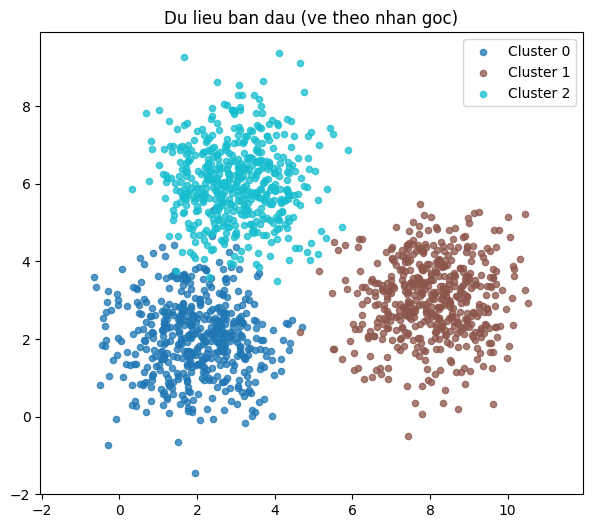

In [4]:
def plot_clusters(X, labels, centers=None, title=''):
    unique_labels = np.unique(labels)
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))

    plt.figure(figsize=(7, 6))
    for idx, label in enumerate(unique_labels):
        Xk = X[labels == label]
        plt.scatter(
            Xk[:, 0], Xk[:, 1],
            s=20, alpha=0.75,
            color=cmap(idx), label=f'Cluster {label}'
        )

    if centers is not None:
        plt.scatter(
            centers[:, 0], centers[:, 1],
            s=220, c='black', marker='X',
            label='Centers'
        )

    plt.title(title)
    plt.axis('equal')
    plt.legend()
    plt.show()


plot_clusters(X, original_label, title='Du lieu ban dau (ve theo nhan goc)')


## 5. Cài đặt K-means từ đầu

Ta sẽ viết lại các hàm cơ bản giống tinh thần của bài gốc:
- `kmeans_init_centers`: khởi tạo tâm ban đầu,
- `kmeans_assign_labels`: gán mỗi điểm vào tâm gần nhất,
- `kmeans_update_centers`: cập nhật tâm bằng trung bình cộng,
- `compute_inertia`: tính tổng bình phương khoảng cách trong cụm,
- `kmeans`: vòng lặp chính của thuật toán.

Trong notebook này, phần tính khoảng cách được viết bằng NumPy broadcasting để không phụ thuộc thêm vào `scipy`.

In [5]:
def kmeans_init_centers(X, K):
    # Chon ngau nhien K diem trong tap du lieu lam tam ban dau.
    indices = np.random.choice(X.shape[0], K, replace=False)
    return X[indices]


def pairwise_distances(X, centers):
    # Tra ve ma tran khoang cach binh phuong, kich thuoc (so_diem, so_tam).
    diff = X[:, None, :] - centers[None, :, :]
    return np.sum(diff ** 2, axis=2)


def kmeans_assign_labels(X, centers):
    distances = pairwise_distances(X, centers)
    return np.argmin(distances, axis=1)


def kmeans_update_centers(X, labels, K, previous_centers=None):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        Xk = X[labels == k]
        if len(Xk) == 0:
            # Truong hop hiem: neu mot cum khong con diem nao, giu nguyen tam cu.
            centers[k] = previous_centers[k]
        else:
            centers[k] = np.mean(Xk, axis=0)
    return centers


def compute_inertia(X, labels, centers):
    total = 0.0
    for k in range(len(centers)):
        Xk = X[labels == k]
        total += np.sum((Xk - centers[k]) ** 2)
    return total


def kmeans(X, K, max_iters=100, tol=1e-6):
    centers = kmeans_init_centers(X, K)
    initial_centers = centers.copy()
    history = []
    previous_labels = None

    for iteration in range(1, max_iters + 1):
        labels = kmeans_assign_labels(X, centers)
        new_centers = kmeans_update_centers(X, labels, K, previous_centers=centers)
        inertia = compute_inertia(X, labels, new_centers)

        history.append({
            'iteration': iteration,
            'labels': labels.copy(),
            'centers': new_centers.copy(),
            'inertia': inertia,
        })

        labels_unchanged = previous_labels is not None and np.array_equal(labels, previous_labels)
        centers_stable = np.allclose(new_centers, centers, atol=tol)

        centers = new_centers
        previous_labels = labels.copy()

        if labels_unchanged or centers_stable:
            break

    return {
        'initial_centers': initial_centers,
        'final_centers': centers,
        'labels': previous_labels,
        'history': history,
    }


## 6. Chạy thuật toán K-means tự cài đặt

Cell dưới đây sẽ:
- khởi tạo các tâm ngẫu nhiên,
- chạy các vòng lặp gán cụm và cập nhật tâm,
- in ra tâm ban đầu, tâm cuối cùng và giá trị hàm mất mát theo từng vòng lặp,
- vẽ kết quả phân cụm cuối cùng.

Tam khoi tao ban dau:
[[1.95180248 6.72897643]
 [1.9444814  3.06716532]
 [3.42144011 0.17309469]]

Tam cuoi cung tim duoc:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]

So vong lap: 6

Gia tri inertia theo tung vong lap:
Lan lap  1: 7818.7917
Lan lap  2: 3075.8628
Lan lap  3: 2998.3398
Lan lap  4: 2997.2169
Lan lap  5: 2997.1495
Lan lap  6: 2997.1495


/tmp/ipykernel_16304/161136290.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


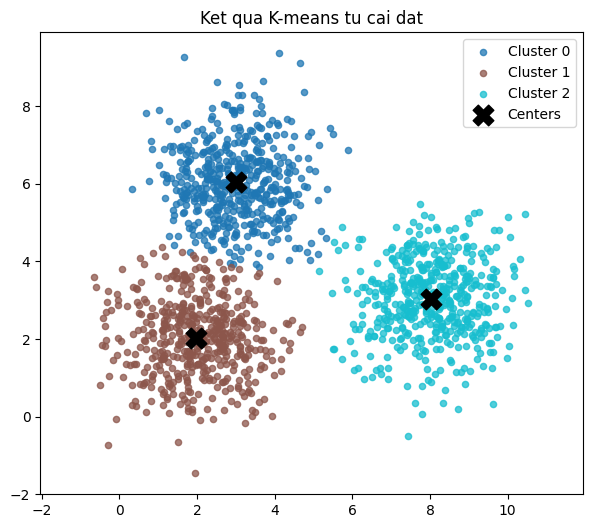

In [6]:
result = kmeans(X, K)

print('Tam khoi tao ban dau:')
print(result['initial_centers'])
print('\nTam cuoi cung tim duoc:')
print(result['final_centers'])
print('\nSo vong lap:', len(result['history']))

print('\nGia tri inertia theo tung vong lap:')
for step in result['history']:
    print(f"Lan lap {step['iteration']:>2}: {step['inertia']:.4f}")

plot_clusters(
    X,
    result['labels'],
    centers=result['final_centers'],
    title='Ket qua K-means tu cai dat'
)


## 7. Quan sát tốc độ hội tụ

Theo phân tích trong bài gốc, hàm mất mát của K-means sẽ giảm dần sau mỗi vòng lặp và thuật toán sẽ dừng sau hữu hạn bước. Ta kiểm tra điều đó bằng cách vẽ `inertia` theo số lần lặp.

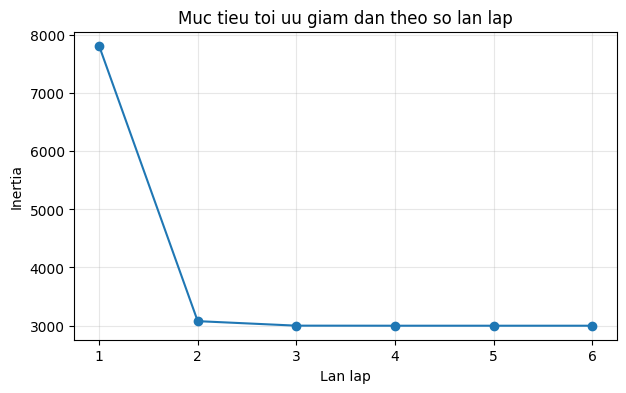

In [7]:
iterations = [step['iteration'] for step in result['history']]
inertias = [step['inertia'] for step in result['history']]

plt.figure(figsize=(7, 4))
plt.plot(iterations, inertias, marker='o')
plt.xticks(iterations)
plt.xlabel('Lan lap')
plt.ylabel('Inertia')
plt.title('Muc tieu toi uu giam dan theo so lan lap')
plt.grid(alpha=0.3)
plt.show()


## 8. So sánh với `scikit-learn`

Bài gốc cũng kiểm tra chéo với `scikit-learn`. Ta làm điều tương tự.

Lưu ý: thứ tự đánh số cụm có thể khác nhau giữa hai cách cài đặt. Ví dụ cụm mà ta gọi là `0` có thể bị thư viện gọi là `2`, nhưng vị trí các tâm vẫn gần nhau.

Tam tim duoc boi scikit-learn:
[[1.97563391 2.01568065]
 [8.0410628  3.02094748]
 [2.99634182 6.03964618]]


/tmp/ipykernel_16304/161136290.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


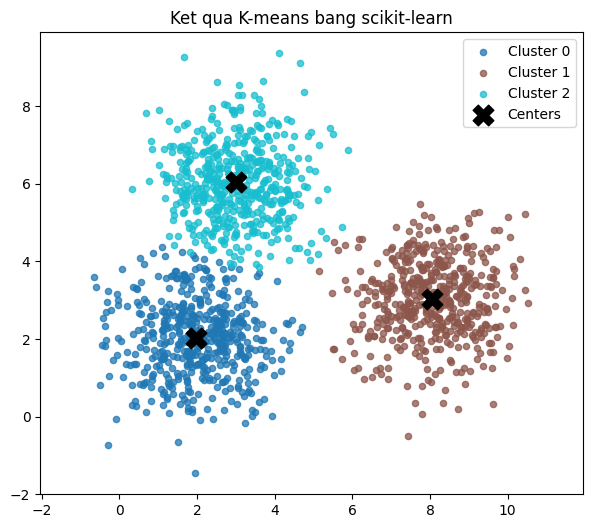

In [8]:
try:
    from sklearn.cluster import KMeans

    sklearn_model = KMeans(n_clusters=K, random_state=11, n_init=10)
    sklearn_labels = sklearn_model.fit_predict(X)

    print('Tam tim duoc boi scikit-learn:')
    print(sklearn_model.cluster_centers_)

    plot_clusters(
        X,
        sklearn_labels,
        centers=sklearn_model.cluster_centers_,
        title='Ket qua K-means bang scikit-learn'
    )
except ImportError:
    print('Moi truong hien tai chua co scikit-learn, bo qua phan so sanh.')


## 9. Nhận xét và hạn chế

Từ bài viết gốc, có vài điểm rất quan trọng cần nhớ:
- phải biết trước số cụm `K`, trong khi thực tế điều này không phải lúc nào cũng rõ,
- kết quả phụ thuộc vào cách khởi tạo tâm ban đầu,
- K-means hoạt động tốt hơn khi các cụm có dạng gần hình tròn và kích thước tương đối cân bằng,
- thuật toán gặp khó khăn với các cụm có hình dạng phức tạp hoặc một cụm nằm bên trong cụm khác.

Dù có hạn chế, K-means vẫn là một trong những thuật toán nền tảng nhất của học không giám sát vì dễ hiểu, dễ cài đặt và thường là điểm khởi đầu rất tốt khi học clustering.